In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, balanced_accuracy_score
from sklearn.preprocessing import LabelEncoder

Loading the data files:

In [3]:
odi_df = pd.read_csv("virat_kohli_odi_innings_data.csv")
t20_df = pd.read_csv("virat_kohli_t20i_innings_data.csv")
test_df = pd.read_csv("virat_kohli_test_innings_data.csv")

Concatenate runs from all the match type and store in Runs

In [4]:
odi_df['Runs'] = pd.to_numeric(odi_df['Runs'], errors='coerce')
t20_df['Runs'] = pd.to_numeric(t20_df['Runs'], errors='coerce')
test_df['Runs'] = pd.to_numeric(test_df['Runs'], errors='coerce')

odi_df['SR'] = pd.to_numeric(odi_df['SR'], errors='coerce')
t20_df['SR'] = pd.to_numeric(t20_df['SR'], errors='coerce')
test_df['SR'] = pd.to_numeric(test_df['SR'], errors='coerce')


The match type data from all csv and store in match_type

In [5]:
runs = np.concatenate((odi_df['Runs'], t20_df['Runs'], test_df['Runs']))
sr = np.concatenate((odi_df['SR'], t20_df['SR'], test_df['SR']))

match_type = np.concatenate((
    np.repeat("ODI", len(odi_df)),
    np.repeat("T20", len(t20_df)),
    np.repeat("TEST", len(test_df))
))

Data frame data_cricketer and storing Runs, SR and match_type

In [7]:
data_cricketer = pd.DataFrame({
    'Runs': runs,
    'SR': sr,
    'Match_Type': match_type
}).dropna()   # remove invalid rows automatically

print(data_cricketer.head())

   Runs     SR Match_Type
0  12.0  54.54        ODI
1  37.0  55.22        ODI
2  25.0  65.78        ODI
3  54.0  81.81        ODI
4  31.0  67.39        ODI


From data_cricketer, strore Runs and SR in X and match_type in Y and Split the data X and Y in x_train, x_test, y_train , y_test:

In [18]:

X = data_cricketer[['Runs', 'SR']]
Y = data_cricketer['Match_Type']

label_encoder = LabelEncoder()
Y_encoded = label_encoder.fit_transform(Y)



X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y_encoded, test_size=0.3, random_state=0
)

print("done")

done


Create SVM Model (Polynomial Degree 6)


In [19]:
model = SVC(kernel='poly', degree=6)
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)

Step 8: Evaluation Metrics

In [20]:
cm = confusion_matrix(Y_test, Y_pred)
acc = accuracy_score(Y_test, Y_pred)
bal_acc = balanced_accuracy_score(Y_test, Y_pred)

print("\nAccuracy:", acc)
print("Balanced Accuracy:", bal_acc)

print("\nClassification Report:\n")
print(classification_report(Y_test, Y_pred, target_names=label_encoder.classes_))


Accuracy: 0.7375
Balanced Accuracy: 0.718055747736113

Classification Report:

              precision    recall  f1-score   support

         ODI       0.77      0.66      0.71        73
         T20       0.89      0.52      0.65        33
        TEST       0.67      0.98      0.80        54

    accuracy                           0.74       160
   macro avg       0.78      0.72      0.72       160
weighted avg       0.76      0.74      0.73       160



Plot Confusion Matrix

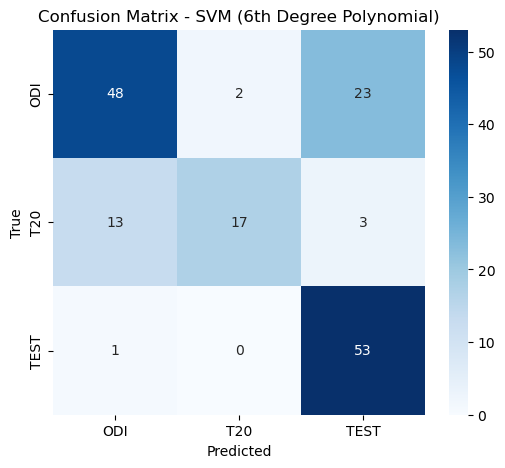

In [21]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=label_encoder.classes_,yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - SVM (6th Degree Polynomial)")
plt.show()

Scatter Plot:


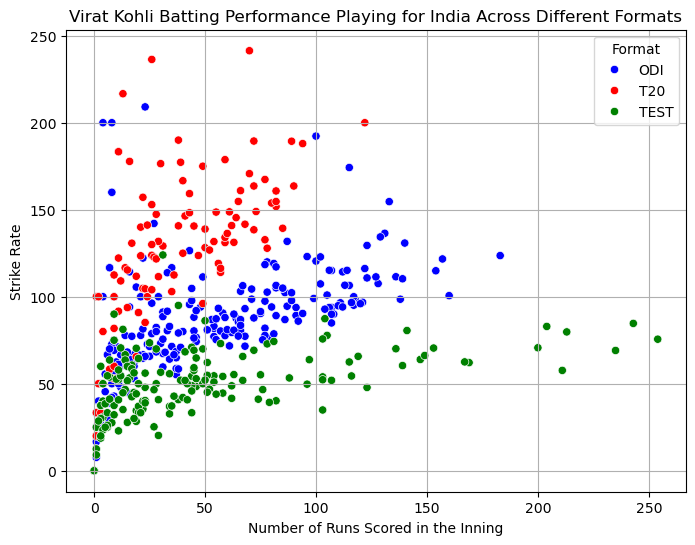

In [23]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=data_cricketer['Runs'], y=data_cricketer['SR'], hue=data_cricketer['Match_Type'], palette=['blue', 'red', 'green'])
plt.xlabel('Number of Runs Scored in the Inning')
plt.ylabel('Strike Rate')
plt.title('Virat Kohli Batting Performance Playing for India Across Different Formats')
plt.legend(title='Format')
plt.grid()
plt.show()

Training polynomial degree 1...
Training polynomial degree 2...
Training polynomial degree 3...
Training polynomial degree 4...
Training polynomial degree 5...
Training polynomial degree 6...
Training polynomial degree 7...
Training polynomial degree 8...
Training polynomial degree 9...
Training polynomial degree 10...
Training polynomial degree 11...
Training polynomial degree 12...
Training polynomial degree 13...
Training polynomial degree 14...
Training polynomial degree 15...


/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_i

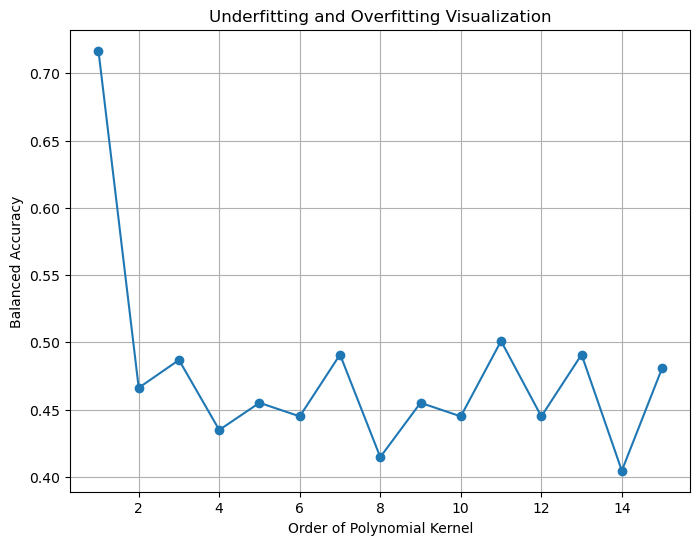

In [26]:
from sklearn.preprocessing import StandardScaler

# Scale the features (VERY IMPORTANT for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

degrees = range(1, 16)
balanced_scores = []

for d in degrees:
    print(f"Training polynomial degree {d}...")  # progress indicator

    temp_model = SVC(
        kernel='poly',
        degree=d,
        gamma='scale',
        max_iter=5000,        # prevents infinite optimization
        cache_size=500
    )

    temp_model.fit(X_train_scaled, Y_train)
    temp_pred = temp_model.predict(X_test_scaled)

    score = balanced_accuracy_score(Y_test, temp_pred)
    balanced_scores.append(score)

# Plot
plt.figure(figsize=(8,6))
plt.plot(degrees, balanced_scores, marker='o')
plt.xlabel("Order of Polynomial Kernel")
plt.ylabel("Balanced Accuracy")
plt.title("Underfitting and Overfitting Visualization")
plt.grid(True)
plt.show()